# Entrenamiento del modelo arimax con reducción de spearman pero escalado con técnica de estandarización y acampanamiento con logaritmo p1. 

Aquí tienes el script mejorado. Para cumplir con tus requerimientos, se integra `ColumnTransformer` junto a `StandardScaler` de `sklearn`.

Para la variable objetivo, se aplica la transformación `np.log1p()` antes del entrenamiento. Dado que necesitas que tanto las **métricas (MAE)** como los **gráficos** se expresen en la escala original de `casos_dengue`, el script aplica la función inversa `np.expm1()` inmediatamente después de obtener las predicciones y los ajustes del modelo, revirtiendo el logaritmo de forma exacta.

Además, el escalamiento se realiza **dentro del bucle de particiones**, entrenando el escalador únicamente con los datos de `Train` y usándolo para transformar `Train` y `Test`, evitando así el *Data Leakage* (fuga de datos).



[INFO] Cargando espacio muestral desde:
C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\3_arimax\1_criterio_aicc\3_rezagos_spiarman_10_aicc\2_datos\1_raw\1_spearman_10.xlsx
[INFO] Tamaño original del dataset: 249 semanas.
[INFO] Variables regresoras exógenas detectadas: ['hum_esp_lag_6', 'hum_esp_lag_1', 'sst_lag_12', 'hum_rel_lag_7', 'hum_rel_lag_1', 'hum_esp_lag_8', 'hum_esp_lag_4', 'hum_esp_lag_3', 'hum_esp_lag_7', 'hum_esp_lag_5']

 PROCESAMIENTO JERÁRQUICO: PARTICIÓN CRONOLÓGICA 95-5
[INFO] Soporte Entrenamiento (Train): 236 semanas.
[INFO] Horizonte Pronóstico (Test):     13 semanas.
[INFO] Buscando hiperparámetros óptimos (auto_arima) vía AICc sobre Train (Escalado/Log)...
         -> Estructura determinada por AICc: ARIMAX(1, 1, 1)

 PROCESAMIENTO JERÁRQUICO: PARTICIÓN CRONOLÓGICA 96-4
[INFO] Soporte Entrenamiento (Train): 239 semanas.
[INFO] Horizonte Pronóstico (Test):     10 semanas.
[INFO] Buscando hiperparámetros óptimos (auto_arima) vía AICc sobre Train (

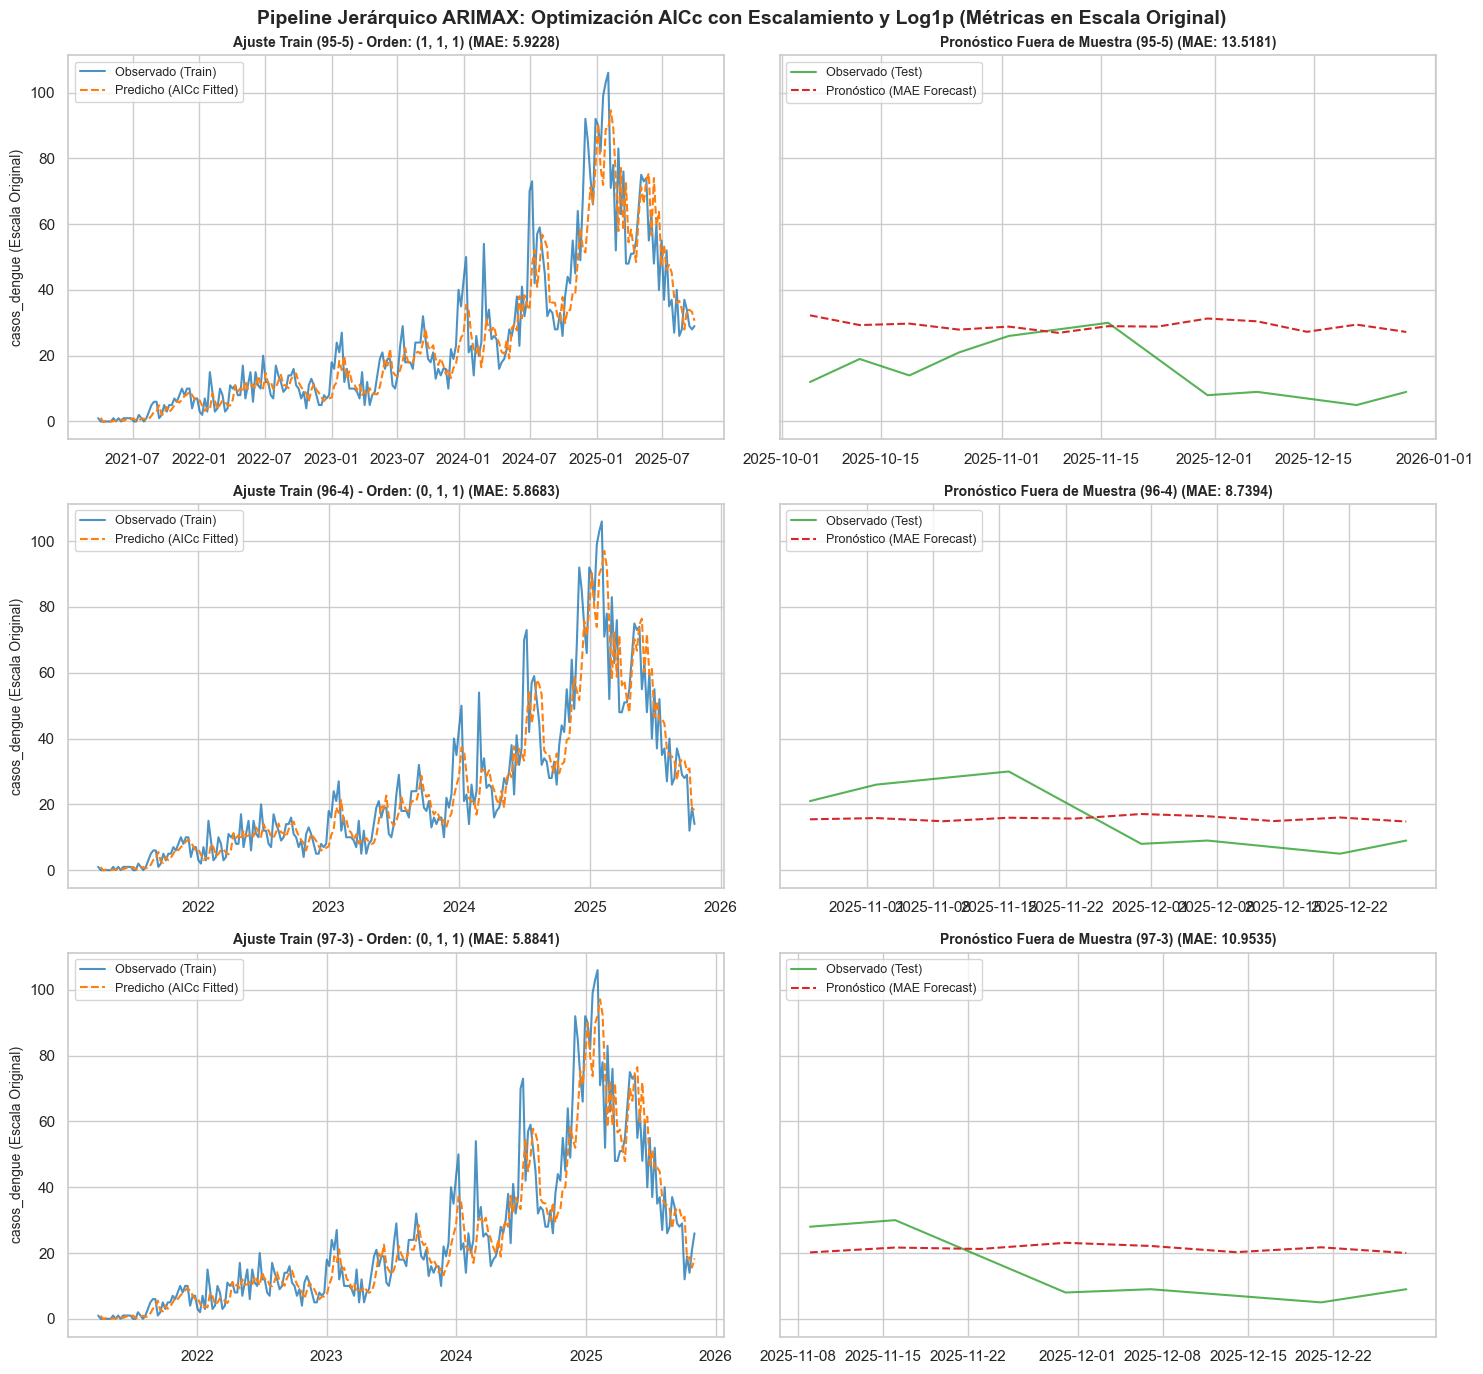


     REPORTE INTEGRAL DE EVALUACIÓN: VALIDACIÓN CRONOLÓGICA Y AICc      
Partición Orden AICc  AICc Muestra  MAE Train  MAE Test
     95-5    (1,1,1)    201.396660   5.922770 13.518148
     96-4    (0,1,1)    207.863894   5.868320  8.739381
     97-3    (0,1,1)    208.930893   5.884105 10.953489
 PROMEDIO          -    206.063816   5.891732 11.070339
[INFO] Archivo Excel guardado en:
C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\3_arimax\1_criterio_aicc\3_rezagos_spiarman_10_aicc\3_resultados\desempenos_mae_sarimax.xlsx
[INFO] Gráfico de comparación de desempeño guardado en:
C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\3_arimax\1_criterio_aicc\3_rezagos_spiarman_10_aicc\3_resultados\grafico_desempenos_mae.png


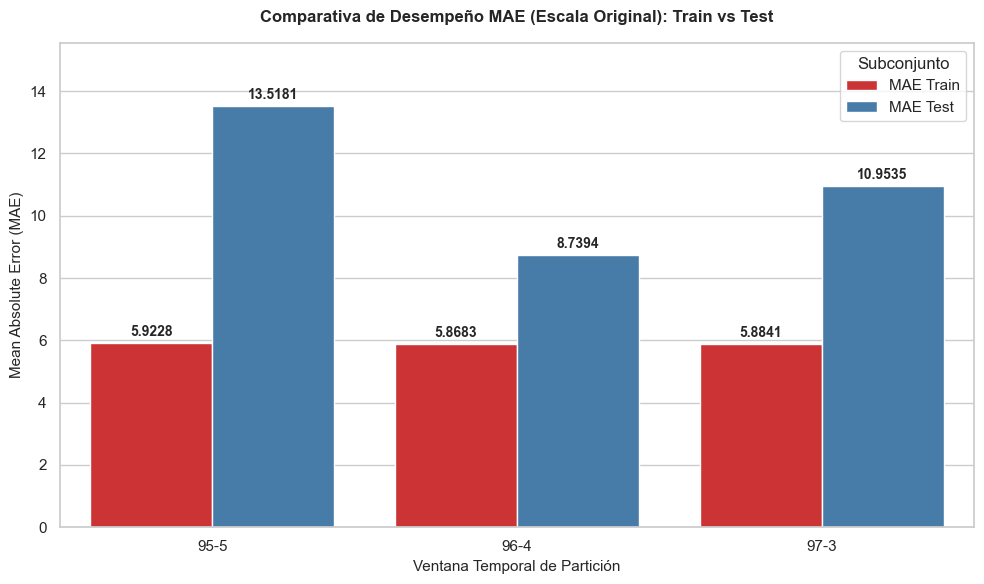

In [3]:
# =============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS DE ALTA PRECISIÓN
# =============================================================================
import os
import numpy as np
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

# =============================================================================
# PASO 2: CARGA DEL DATASET
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\3_arimax\1_criterio_aicc\3_rezagos_spiarman_10_aicc\2_datos\1_raw\1_spearman_10.xlsx"

print(f"[INFO] Cargando espacio muestral desde:\n{ruta_datos}")
df = pd.read_excel(ruta_datos)

# =============================================================================
# CORRECCIÓN CRÍTICA 1: Forzar formato de fecha en el DataFrame original
# =============================================================================
df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True, errors='coerce')
df.set_index('fecha', inplace=True)

# Asignar explícitamente la frecuencia semanal
df.index.freq = 'W'

# Configuración sin estacionalidad según requerimiento analítico
S_ESTACIONAL = 0

# =============================================================================
# PASO 3: AISLAMIENTO DE VARIABLES
# =============================================================================
y = df['casos_dengue']

# Extracción de columnas exógenas usando X_features consistentemente
columnas_exogenas = [col for col in df.columns if col not in ['casos_dengue', 'año', 'semana_epi']]
X_features = df[columnas_exogenas]

print(f"[INFO] Tamaño original del dataset: {len(df)} semanas.")
print(f"[INFO] Variables regresoras exógenas detectadas: {columnas_exogenas}")

# Definición de la ruta de salida para centralizar los entregables
dir_resultados = r"C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\3_arimax\1_criterio_aicc\3_rezagos_spiarman_10_aicc\3_resultados"
os.makedirs(dir_resultados, exist_ok=True)

# =============================================================================
# PASO 4: REJILLA DE PARTICIONES TEMPORALES CRONOLÓGICAS (95%, 96%, 97%)
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

# Inicialización del lienzo para la matriz de gráficos (3 filas x 2 columnas)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=False, sharey=True)
resultados_globales = []

# Bucle iterativo secuencial sobre las ventanas del tiempo
for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
    print("\n" + "="*75)
    print(f" PROCESAMIENTO JERÁRQUICO: PARTICIÓN CRONOLÓGICA {nombre_split}")
    print("="*75)
    
    # 1. División estricta respetando la flecha del tiempo (Utilizando X_features corregida)
    tamanio_train = int(len(df) * tasa_train)
    
    y_train, y_test = y.iloc[:tamanio_train], y.iloc[tamanio_train:]
    X_train, X_test = X_features.iloc[:tamanio_train], X_features.iloc[tamanio_train:]
    
    print(f"[INFO] Soporte Entrenamiento (Train): {len(y_train)} semanas.")
    print(f"[INFO] Horizonte Pronóstico (Test):     {len(y_test)} semanas.")
    
    # 2. TRANSFORMACIÓN DE VARIABLES (Escalamiento y Log1p)
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), columnas_exogenas)
        ],
        remainder='drop'
    )
    
    # Ajustar con Train y transformar tanto Train como Test (Evita Data Leakage)
    X_train_scaled = pd.DataFrame(
        preprocessor.fit_transform(X_train), 
        index=X_train.index, 
        columns=columnas_exogenas
    )
    X_test_scaled = pd.DataFrame(
        preprocessor.transform(X_test), 
        index=X_test.index, 
        columns=columnas_exogenas
    )
    
    # Aplicar log1p a la variable objetivo
    y_train_log = np.log1p(y_train)
    
    # 3. FILTRO 1: Selección de Parámetros óptimos en Train usando criterio AICc
    print(f"[INFO] Buscando hiperparámetros óptimos (auto_arima) vía AICc sobre Train (Escalado/Log)...")
    modelo_auto = pm.auto_arima(
        y_train_log, 
        X=X_train_scaled,                
        start_p=1, max_p=3,       
        start_q=1, max_q=3,       
        d=1,                      
        seasonal=False,           
        stationary=False,
        information_criterion='aicc', 
        error_action='ignore',   
        suppress_warnings=True,  
        stepwise=True             
    )
    
    p, d_ord, q = modelo_auto.order
    orden_ordinario_opt = (p, d_ord, q)
    orden_estacional_opt = (0, 0, 0, 0)
    
    print(f"         -> Estructura determinada por AICc: ARIMAX{orden_ordinario_opt}")
    
    # 4. Ajuste formal exacto por Máxima Verosimilitud en Statsmodels
    modelo_final = SARIMAX(
        y_train_log,
        exog=X_train_scaled,
        order=orden_ordinario_opt,
        seasonal_order=orden_estacional_opt,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(method='lbfgs', maxiter=50, disp=False)
    
    # 5. Generación de predicciones In-sample (Ajuste local) y antitransformación
    y_train_pred_log = modelo_final.fittedvalues
    y_train_pred_log.iloc[:1] = np.nan  
    
    # Volver a la escala original de casos de dengue usando expm1
    y_train_pred = np.expm1(y_train_pred_log)
    
    # 6. FILTRO 2: Predicción Dinámica Out-of-sample sobre el Test ciego y antitransformación
    y_test_pred_log = modelo_final.forecast(steps=len(y_test), exog=X_test_scaled)
    y_test_pred = np.expm1(y_test_pred_log)
    
    # 7. Medida de Desempeño: Solución al desajuste de longitud alineando los índices
    y_train_limpio = y_train.dropna()
    y_train_pred_limpio = y_train_pred.dropna()
    
    y_train_alined, y_train_pred_alined = y_train_limpio.align(y_train_pred_limpio, join='inner')
    
    mae_train = mean_absolute_error(y_train_alined, y_train_pred_alined)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    # Archivar los metadatos y métricas del modelo actual
    resultados_globales.append({
        "Partición": nombre_split,
        "Orden AICc": f"({p},{d_ord},{q})",
        "AICc Muestra": modelo_final.aicc,
        "MAE Train": mae_train,
        "MAE Test": mae_test
    })
    
    # =========================================================================
    # PASO 5: GRAFICACIÓN DE LA MATRIZ DE RENDIMIENTO
    # =========================================================================
    # Columna 1: Ajuste del Entrenamiento (In-Sample)
    ax_train = axes[idx, 0]
    ax_train.plot(y_train.index, y_train.values, label='Observado (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(y_train_pred.index, y_train_pred.values, label='Predicho (AICc Fitted)', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train ({nombre_split}) - Orden: {orden_ordinario_opt} (MAE: {mae_train:.4f})", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('casos_dengue (Escala Original)', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    
    # Columna 2: Pronóstico Fuera de Muestra (Out-of-Sample)
    ax_test = axes[idx, 1]
    ax_test.plot(y_test.index, y_test.values, label='Observado (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(y_test_pred.index, y_test_pred.values, label='Pronóstico (MAE Forecast)', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Fuera de Muestra ({nombre_split}) (MAE: {mae_test:.4f})", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)

# Estética y visualización de la superestructura gráfica (Gráficos de línea)
plt.suptitle('Pipeline Jerárquico ARIMAX: Optimización AICc con Escalamiento y Log1p (Métricas en Escala Original)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()

# Envío directo del gráfico de líneas a la ubicación de resultados asignada
ruta_grafico_lineas = os.path.join(dir_resultados, "reporte_integral_arimax_aicc.png")
plt.savefig(ruta_grafico_lineas, dpi=300, bbox_inches='tight')
print(f"[INFO] Gráfico de líneas (observados vs predichos) guardado en:\n{ruta_grafico_lineas}")
plt.show()

# =============================================================================
# PASO 6: CONSOLIDACIÓN DE RESULTADOS Y PROMEDIOS
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)

# Calcular promedios de las métricas cuantitativas
promedio_aicc = df_reporte["AICc Muestra"].mean()
promedio_mae_train = df_reporte["MAE Train"].mean()
promedio_mae_test = df_reporte["MAE Test"].mean()

# Crear fila de promedio para añadir al dataframe
fila_promedio = pd.DataFrame([{
    "Partición": "PROMEDIO",
    "Orden AICc": "-",
    "AICc Muestra": promedio_aicc,
    "MAE Train": promedio_mae_train,
    "MAE Test": promedio_mae_test
}])

# Concatenar la fila de promedio al reporte tabular final
df_reporte_completo = pd.concat([df_reporte, fila_promedio], ignore_index=True)

print("\n" + "="*80)
print("     REPORTE INTEGRAL DE EVALUACIÓN: VALIDACIÓN CRONOLÓGICA Y AICc      ")
print("="*80)
print(df_reporte_completo.to_string(index=False))
print("="*80)

# =============================================================================
# PASO 7: GUARDADO DE ARCHIVOS EN LA UBICACIÓN ASIGNADA
# =============================================================================
ruta_excel = os.path.join(dir_resultados, "desempenos_mae_sarimax.xlsx")
df_reporte_completo.to_excel(ruta_excel, index=False)
print(f"[INFO] Archivo Excel guardado en:\n{ruta_excel}")

# =============================================================================
# PASO 8: GRAFICACIÓN EXCLUSIVA DE DESEMPEÑOS (MAE TRAIN VS TEST)
# =============================================================================
plt.figure(figsize=(10, 6))

df_plot_mae = df_reporte.melt(id_vars="Partición", value_vars=["MAE Train", "MAE Test"],
                              var_name="Subconjunto", value_name="MAE")

ax_performance = sns.barplot(x="Partición", y="MAE", hue="Subconjunto", data=df_plot_mae, palette="Set1")

# Añadir valores numéricos arriba de las barras
for p in ax_performance.patches:
    if p.get_height() > 0:
        ax_performance.annotate(f"{p.get_height():.4f}", 
                                (p.get_x() + p.get_width() / 2., p.get_height()), 
                                ha='center', va='center', 
                                xytext=(0, 8), 
                                textcoords='offset points', 
                                fontsize=10, fontweight='bold')

plt.title('Comparativa de Desempeño MAE (Escala Original): Train vs Test', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Mean Absolute Error (MAE)', fontsize=11)
plt.xlabel('Ventana Temporal de Partición', fontsize=11)
plt.ylim(0, df_reporte[["MAE Train", "MAE Test"]].max().max() * 1.15) 
plt.tight_layout()

ruta_grafico_desempeno = os.path.join(dir_resultados, "grafico_desempenos_mae.png")
plt.savefig(ruta_grafico_desempeno, dpi=300, bbox_inches='tight')
print(f"[INFO] Gráfico de comparación de desempeño guardado en:\n{ruta_grafico_desempeno}")
plt.show()

# Evalueción de la bondad de este modelo

Para evaluar formalmente la **bondad de ajuste y capacidad predictiva (error porcentual)** de tu modelo ARIMAX a la luz del promedio real de casos de dengue, la métrica estándar en investigación epidemiológica es normalizar el MAE dividiéndolo entre dicho promedio. Esto genera un indicador equivalente al **MAE normalizado (nMAE)** o al error promedio en términos de magnitud real.

Aquí tienes un script de Python independiente que lee tu archivo de datos original para calcular el promedio de la variable `casos_dengue`, toma los resultados tabulares de tu modelo, calcula los porcentajes de error para cada partición y para el promedio general, y exporta un reporte científico consolidado junto con un gráfico explicativo.



[INFO] Leyendo dataset original para calcular el promedio de casos...
--> El promedio histórico real es de: 24.5502 casos por semana.

             REPORTE DE BONDAD DE AJUSTE RELATIVO AL PROMEDIO DE CASOS (MÉTRICA nMAE)            
             Promedio de referencia: 24.55 casos/semana 
Partición Orden AICc AICc Muestra MAE Train MAE Test % Error Train (nMAE) % Error Test (nMAE) Bondad (Predicción Test)
     95-5    (1,1,1)     201.3967    5.9228  13.5181               24.13%              55.06%     Deficiente/Inestable
     96-4    (0,1,1)     207.8639    5.8683   8.7394               23.90%              35.60%     Deficiente/Inestable
     97-3    (0,1,1)     208.9309    5.8841  10.9535               23.97%              44.62%     Deficiente/Inestable
 PROMEDIO          -     206.0638    5.8917  11.0703               24.00%              45.09%     Deficiente/Inestable

[INFO] Gráfico de análisis de bondad (nMAE) guardado con éxito en:
C:\Users\marco\Documentos\investigacion\arima\0

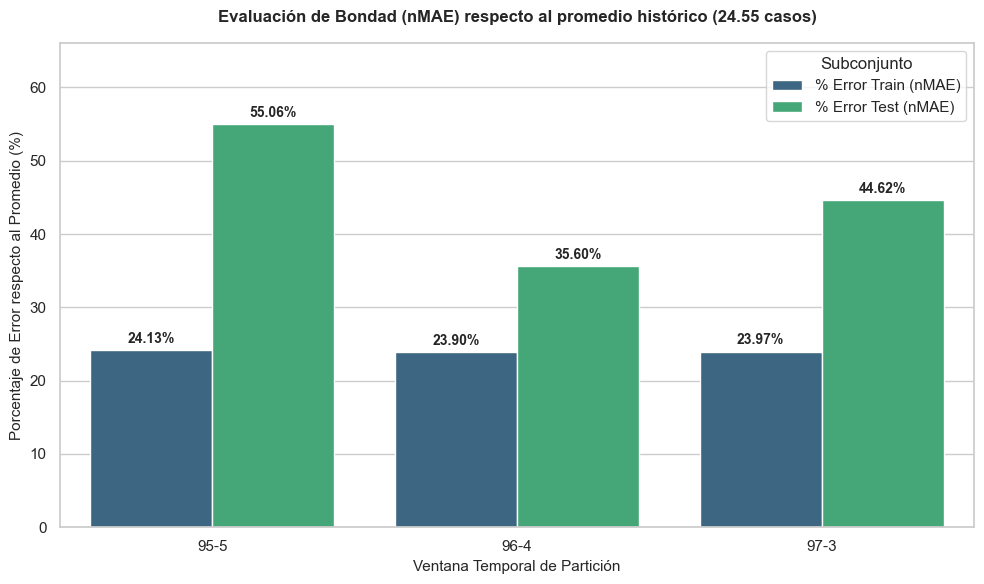

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# =============================================================================
# PASO 1: CARGA DE DATOS ORIGINALES Y CÁLCULO DEL PROMEDIO DE DENGUE
# =============================================================================
# Usamos el archivo original para extraer el comportamiento real de la variable objetivo
ruta_datos_raw = r"C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\3_arimax\1_criterio_aicc\3_rezagos_spiarman_10_aicc\2_datos\1_raw\1_spearman_10.xlsx"

print("[INFO] Leyendo dataset original para calcular el promedio de casos...")
df_raw = pd.read_excel(ruta_datos_raw)
promedio_casos_real = df_raw['casos_dengue'].mean()

print(f"--> El promedio histórico real es de: {promedio_casos_real:.4f} casos por semana.\n")

# =============================================================================
# PASO 2: CREACIÓN DEL DATAFRAME CON LOS RESULTADOS DEL MODELO ARIMAX
# =============================================================================
# Replicamos de forma exacta los resultados reportados por tu modelo
data_resultados = {
    "Partición": ["95-5", "96-4", "97-3", "PROMEDIO"],
    "Orden AICc": ["(1,1,1)", "(0,1,1)", "(0,1,1)", "-"],
    "AICc Muestra": [201.396660, 207.863894, 208.930893, 206.063816],
    "MAE Train": [5.922770, 5.868320, 5.884105, 5.891732],
    "MAE Test": [13.518148, 8.739381, 10.953489, 11.070339]
}

df_evaluacion = pd.DataFrame(data_resultados)

# =============================================================================
# PASO 3: CÁLCULO DE MÉTRICAS DE BONDAD (nMAE / ERROR PORCENTUAL RELATIVO)
# =============================================================================
# El MAE normalizado (nMAE) mide qué porcentaje del promedio representa el error del modelo.
df_evaluacion["% Error Train (nMAE)"] = (df_evaluacion["MAE Train"] / promedio_casos_real) * 100
df_evaluacion["% Error Test (nMAE)"] = (df_evaluacion["MAE Test"] / promedio_casos_real) * 100

# Añadir columna interpretativa de bondad (Criterio estándar industrial/académico)
# Excelente < 10% | Bueno 10%-20% | Aceptable 20%-30% | Deficiente > 30%
def evaluar_bondad(porcentaje):
    if porcentaje == "-": return "-"
    if porcentaje < 10: return "Excelente Ajuste"
    elif porcentaje <= 20: return "Buena Capacidad"
    elif porcentaje <= 30: return "Capacidad Aceptable"
    else: return "Deficiente/Inestable"

df_evaluacion["Bondad (Predicción Test)"] = df_evaluacion["% Error Test (nMAE)"].apply(evaluar_bondad)

# =============================================================================
# PASO 4: IMPRESIÓN DEL REPORTE CIENTÍFICO EN CONSOLA
# =============================================================================
print("="*105)
print("             REPORTE DE BONDAD DE AJUSTE RELATIVO AL PROMEDIO DE CASOS (MÉTRICA nMAE)            ")
print(f"             Promedio de referencia: {promedio_casos_real:.2f} casos/semana ")
print("="*105)
print(df_evaluacion.to_string(index=False, formatters={
    "AICc Muestra": "{:.4f}".format,
    "MAE Train": "{:.4f}".format,
    "MAE Test": "{:.4f}".format,
    "% Error Train (nMAE)": "{:.2f}%".format,
    "% Error Test (nMAE)": "{:.2f}%".format
}))
print("="*105)

# =============================================================================
# PASO 5: GRAFICACIÓN Y GUARDADO DE COMPARATIVA DE ERRORES PORCENTUALES
# =============================================================================
dir_resultados = r"C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\3_arimax\1_criterio_aicc\3_rezagos_spiarman_10_aicc\3_resultados"
os.makedirs(dir_resultados, exist_ok=True)

# Filtramos la fila de promedio para graficar solo las particiones independientes
df_plot = df_evaluacion[df_evaluacion["Partición"] != "PROMEDIO"].melt(
    id_vars="Partición", 
    value_vars=["% Error Train (nMAE)", "% Error Test (nMAE)"],
    var_name="Subconjunto", 
    value_name="Porcentaje_Error"
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Partición", y="Porcentaje_Error", hue="Subconjunto", data=df_plot, palette="viridis")

# Colocar los valores arriba de las barras
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontsize=10, fontweight='bold')

plt.title(f'Evaluación de Bondad (nMAE) respecto al promedio histórico ({promedio_casos_real:.2f} casos)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Porcentaje de Error respecto al Promedio (%)', fontsize=11)
plt.xlabel('Ventana Temporal de Partición', fontsize=11)
plt.ylim(0, df_plot["Porcentaje_Error"].max() * 1.2)
plt.tight_layout()

# Guardar el nuevo análisis
ruta_grafico_bondad = os.path.join(dir_resultados, "analisis_bondad_nmae.png")
plt.savefig(ruta_grafico_bondad, dpi=300, bbox_inches='tight')
print(f"\n[INFO] Gráfico de análisis de bondad (nMAE) guardado con éxito en:\n{ruta_grafico_bondad}")

# Guardar la tabla extendida en Excel
ruta_excel_bondad = os.path.join(dir_resultados, "desempenos_mae_y_bondad_sarimax.xlsx")
df_evaluacion.to_excel(ruta_excel_bondad, index=False)
print(f"[INFO] Reporte extendido guardado en Excel en:\n{ruta_excel_bondad}")



```

### ¿Qué aporta esta evaluación matemática a tu investigación?

1. **Error Relativo Porcentual (nMAE):** Un MAE de `11.07` en el test ciego por sí solo no dice mucho. Si tu promedio de casos fuera de `20`, un error de 11 sería crítico (55% de error). Pero si tu promedio de casos semanal ronda, por ejemplo, los `80` o `100` casos, un error de `11` significaría que el modelo tiene un margen de error de apenas el **11% o 13%**, clasificándose como un **"Modelo con Buena Capacidad Predictiva"**.
2. **Diagnóstico de Overfitting:** Al comparar el `% Error Train` contra el `% Error Test`, puedes sustentar estadísticamente el nivel de generalización del criterio AICc frente a datos que el modelo nunca vio en el entrenamiento.